# TP : Prédiction du taux de désabonnement ou perte de clients (Telco Customer Churn)

Ce notebook présente l'analyse exploratoire des données (EDA), la préparation des caractéristiques (feature engineering) et la mise en œuvre de modèles de classification pour prédire le désabonnement des clients.

Nous entraînons et évaluons trois modèles :
1. **K-Nearest Neighbors (KNN)**
2. **Régression Logistique**
3. **Réseau de Neurones (MLP)**

## Introduction
La perte de clientèle (ou *churn*) est un problème majeur dans le secteur des télécommunications. L'objectif de ce projet est de prédire à l'avance quels clients présentent un risque élevé de désabonnement afin de cibler les efforts de fidélisation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc, f1_score, ConfusionMatrixDisplay, precision_score, recall_score


## Chargement des données


In [2]:
# Chargement de l'ensemble de données
df = pd.read_csv("../WA_Fn-UseC_-Telco-Customer-Churn.csv", index_col='customerID')
print(f"Dimensions de l'ensemble de données : {df.shape}")
df.head()


Dimensions de l'ensemble de données : (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploration des valeurs uniques de chaque colonne


In [3]:
f_columns = df.columns.tolist()
for column in f_columns:
    print(f"{column} unique values : {df[column].unique()[:10]}...")


gender unique values : <StringArray>
['Female', 'Male']
Length: 2, dtype: str...
SeniorCitizen unique values : [0 1]...
Partner unique values : <StringArray>
['Yes', 'No']
Length: 2, dtype: str...
Dependents unique values : <StringArray>
['No', 'Yes']
Length: 2, dtype: str...
tenure unique values : [ 1 34  2 45  8 22 10 28 62 13]...
PhoneService unique values : <StringArray>
['No', 'Yes']
Length: 2, dtype: str...
MultipleLines unique values : <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str...
InternetService unique values : <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str...
OnlineSecurity unique values : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str...
OnlineBackup unique values : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str...
DeviceProtection unique values : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str...
TechSupport unique values : <StringArray>
['No', 'Yes', 'No

## Analyse exploratoire des données (EDA) & Statistiques descriptives


In [4]:
# Statistiques descriptives pour les variables numériques
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Types de données et valeurs non-nulles
df.info()


<class 'pandas.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 

### Nettoyage des données
1. Conversion de la colonne `TotalCharges` en float (elle est stockée en tant qu'objet en raison de valeurs manquantes constituées d'espaces).
2. Nettoyage de la colonne `PaymentMethod` (suppression de la mention " (automatic)" pour simplifier les étiquettes).
3. Inspection et suppression des valeurs manquantes.


In [6]:
# Conversion de TotalCharges en float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Suppression de " (automatic)" dans PaymentMethod
df["PaymentMethod"] = df["PaymentMethod"].str.replace(" (automatic)", "", regex=False)

# Vérification du nombre de valeurs manquantes
features_na = [feature for feature in df.columns if df[feature].isnull().sum() > 0]
for feature in features_na:
    print(f"{feature}: {df[feature].isnull().sum()} valeurs manquantes ({round(df[feature].isnull().mean()*100, 4)} %)")


TotalCharges: 11 valeurs manquantes (0.1562 %)


In [7]:
# Suppression des lignes contenant des valeurs manquantes
df.dropna(inplace=True)
print(f"Nouvelles dimensions du dataset après suppression des NaNs : {df.shape}")


Nouvelles dimensions du dataset après suppression des NaNs : (7032, 20)


## Visualisation de la variable cible (`Churn`)


C:\Users\karlh\AppData\Local\Temp\ipykernel_25508\206879065.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = df["Churn"], palette="Blues")


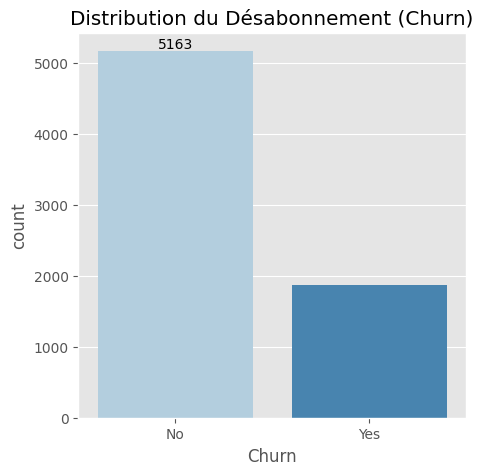

In [8]:
# Style des graphiques
plt.style.use("ggplot")
plt.figure(figsize=(5,5))
ax = sns.countplot(x = df["Churn"], palette="Blues")
ax.bar_label(ax.containers[0])
plt.title("Distribution du Désabonnement (Churn)")
plt.show()


Le dataset est déséquilibré : la majorité des clients reste fidèle (No). Pour évaluer nos modèles de manière équitable, nous ferons attention à utiliser des métriques comme l'AUC ROC, le F1-Score et la courbe Precision-Recall en plus de l'Accuracy.


## Analyse des services souscrits par les clients


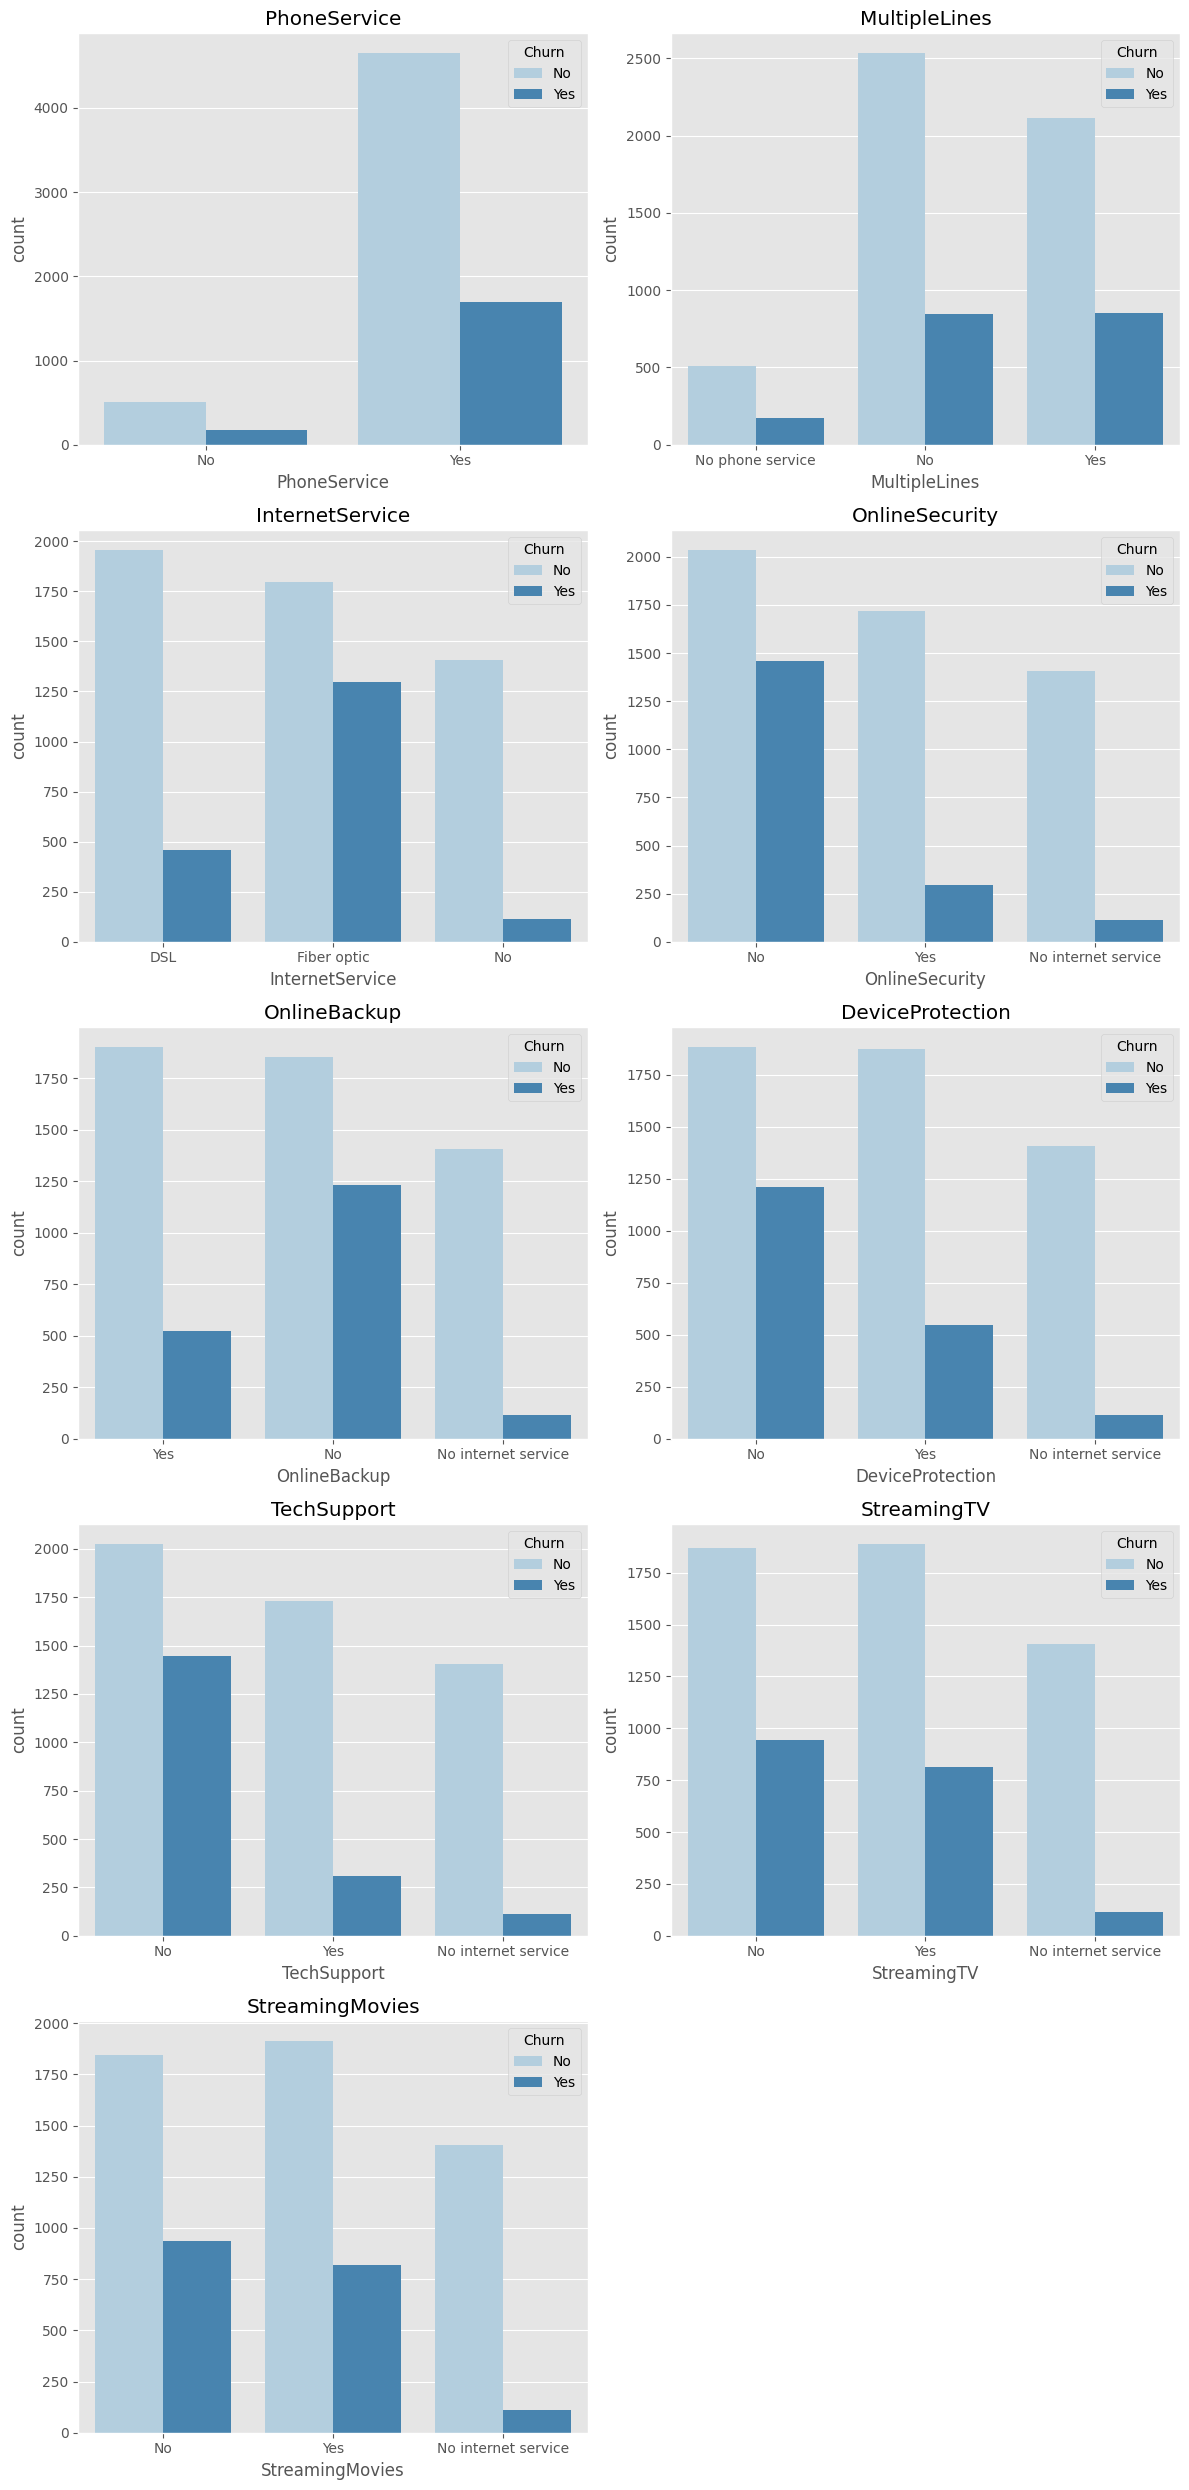

In [9]:
# Fonction générique pour tracer les variables catégorielles en fonction de la cible
def plot_categorical_to_target(df, categorical_values, target):
    number_of_columns = 2
    number_of_rows = math.ceil(len(categorical_values) / number_of_columns)
    
    fig = plt.figure(figsize=(12, 5 * number_of_rows))
    
    for index, column in enumerate(categorical_values, 1):
        ax = fig.add_subplot(number_of_rows, number_of_columns, index)
        sns.countplot(x=column, data=df, hue=target, palette="Blues", ax=ax)
        ax.set_title(column)
    plt.tight_layout()
    plt.show()

customer_services = [
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

plot_categorical_to_target(df, customer_services, "Churn")


### Conclusions sur les services :
- Les clients disposant du service Internet par **Fibre Optique** présentent un taux de désabonnement nettement supérieur à ceux sur DSL ou sans Internet.
- Les clients n'ayant **pas de sécurité en ligne (OnlineSecurity)** ni d'**assistance technique (TechSupport)** sont beaucoup plus susceptibles de se désabonner.


## Analyse des informations de compte (Variables catégorielles)


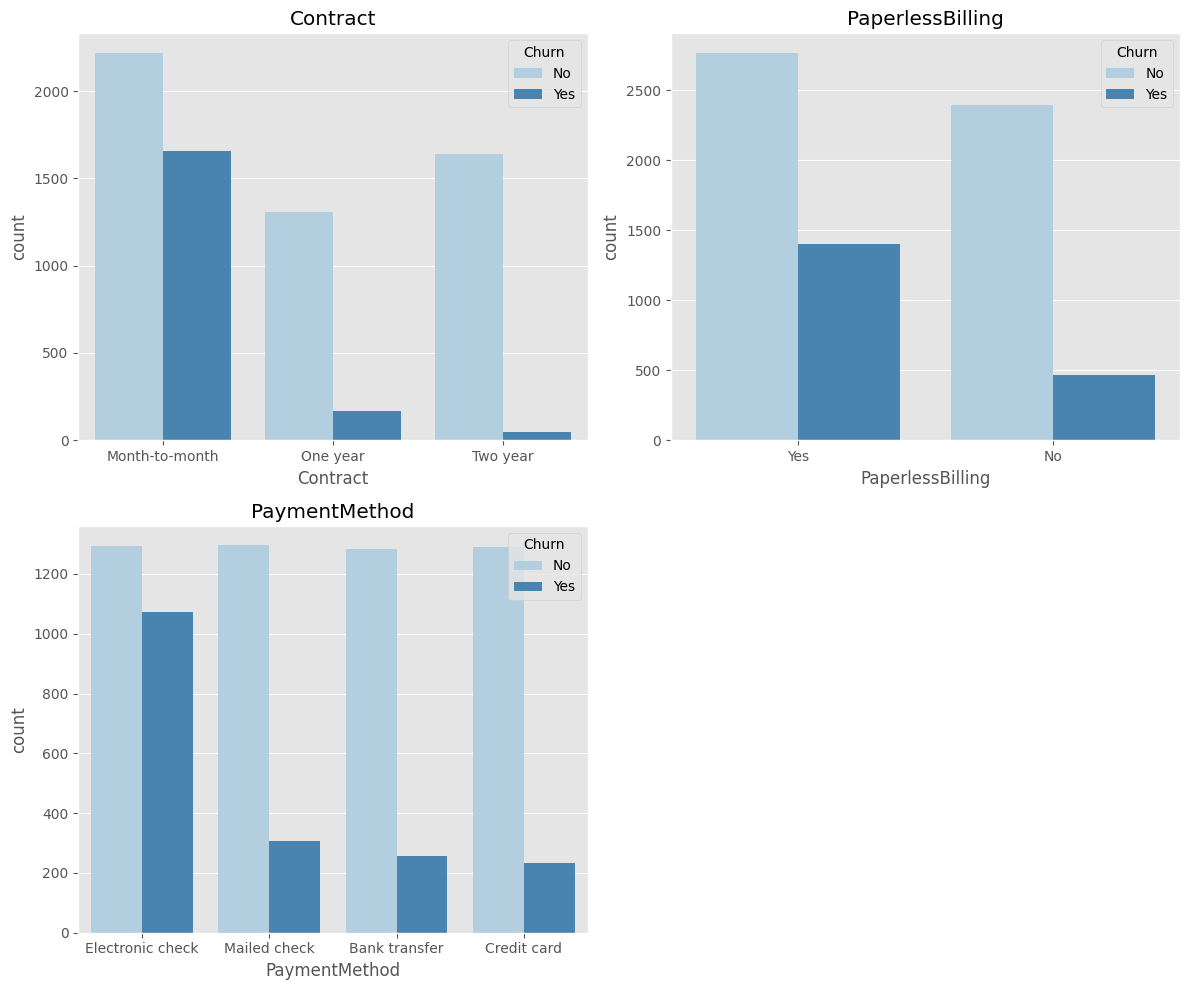

In [10]:
customer_account_cat = ["Contract", "PaperlessBilling", "PaymentMethod"]
plot_categorical_to_target(df, customer_account_cat, "Churn")


### Conclusions sur le compte client :
- Les clients ayant un contrat **mois par mois (Month-to-month)** se désabonnent massivement.
- Le mode de paiement par **chèque électronique (Electronic check)** est fortement associé au désabonnement.
- Les clients bénéficiant de la facturation sans papier (PaperlessBilling) ont un taux de désabonnement supérieur.


## Analyse des variables numériques du compte client (Distribution)


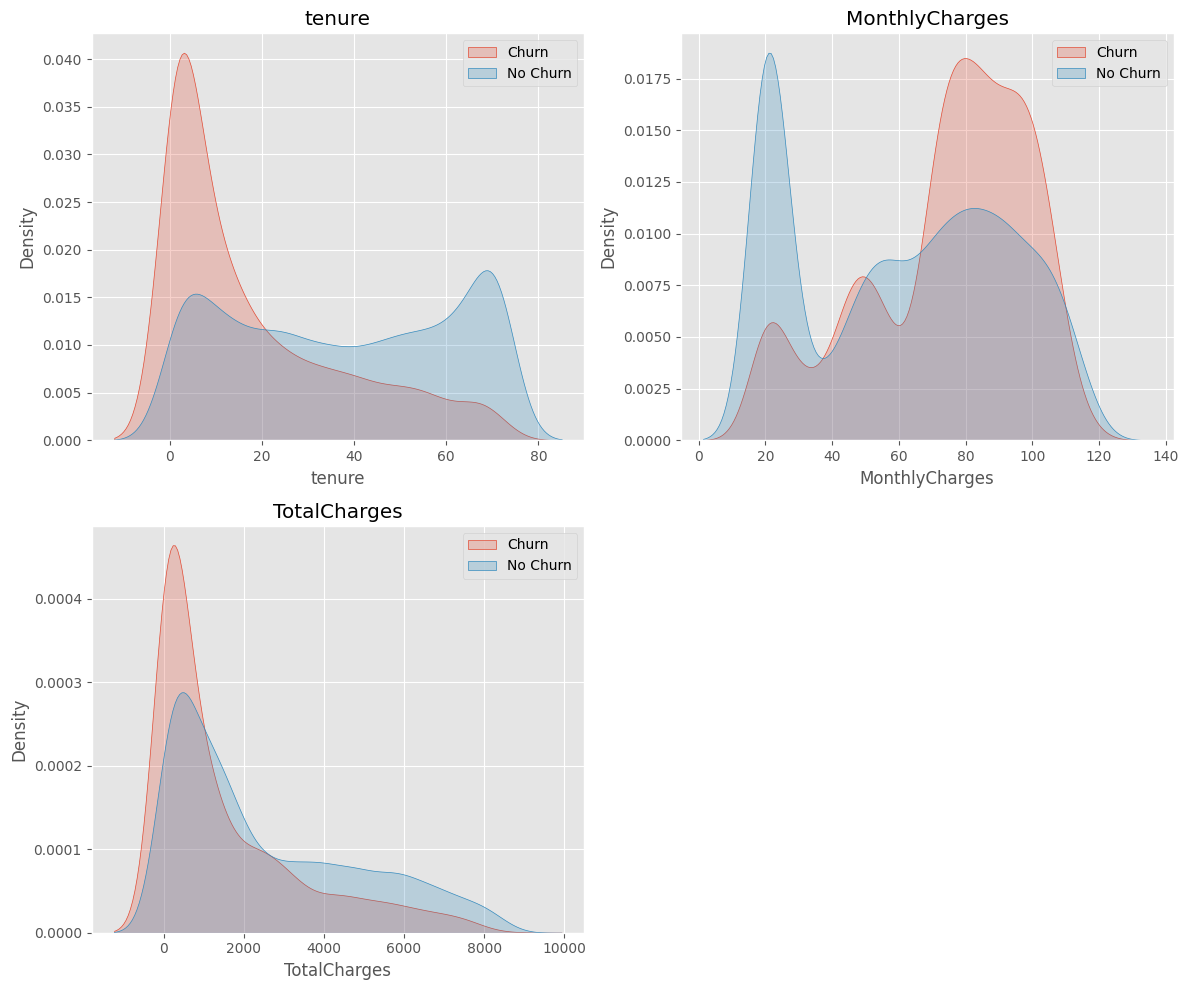

In [11]:
def histogram_plots(df, numerical_values, target):
    number_of_columns = 2
    number_of_rows = math.ceil(len(numerical_values) / number_of_columns)
    
    fig = plt.figure(figsize=(12, 5 * number_of_rows))
    
    for index, column in enumerate(numerical_values, 1):
        ax = fig.add_subplot(number_of_rows, number_of_columns, index)
        sns.kdeplot(df[column][df[target] == "Yes"], fill=True, label="Churn", ax=ax)
        sns.kdeplot(df[column][df[target] == "No"], fill=True, label="No Churn", ax=ax)
        ax.set_title(column)
        ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

customer_account_num = ["tenure", "MonthlyCharges", "TotalCharges"]
histogram_plots(df, customer_account_num, "Churn")


### Conclusions sur les variables numériques :
- Les clients ayant une **courte durée d'ancienneté (tenure)** sont très susceptibles de se désabonner.
- Les frais mensuels (MonthlyCharges) plus élevés sont corrélés avec un risque de désabonnement supérieur.


## Analyse des caractéristiques démographiques


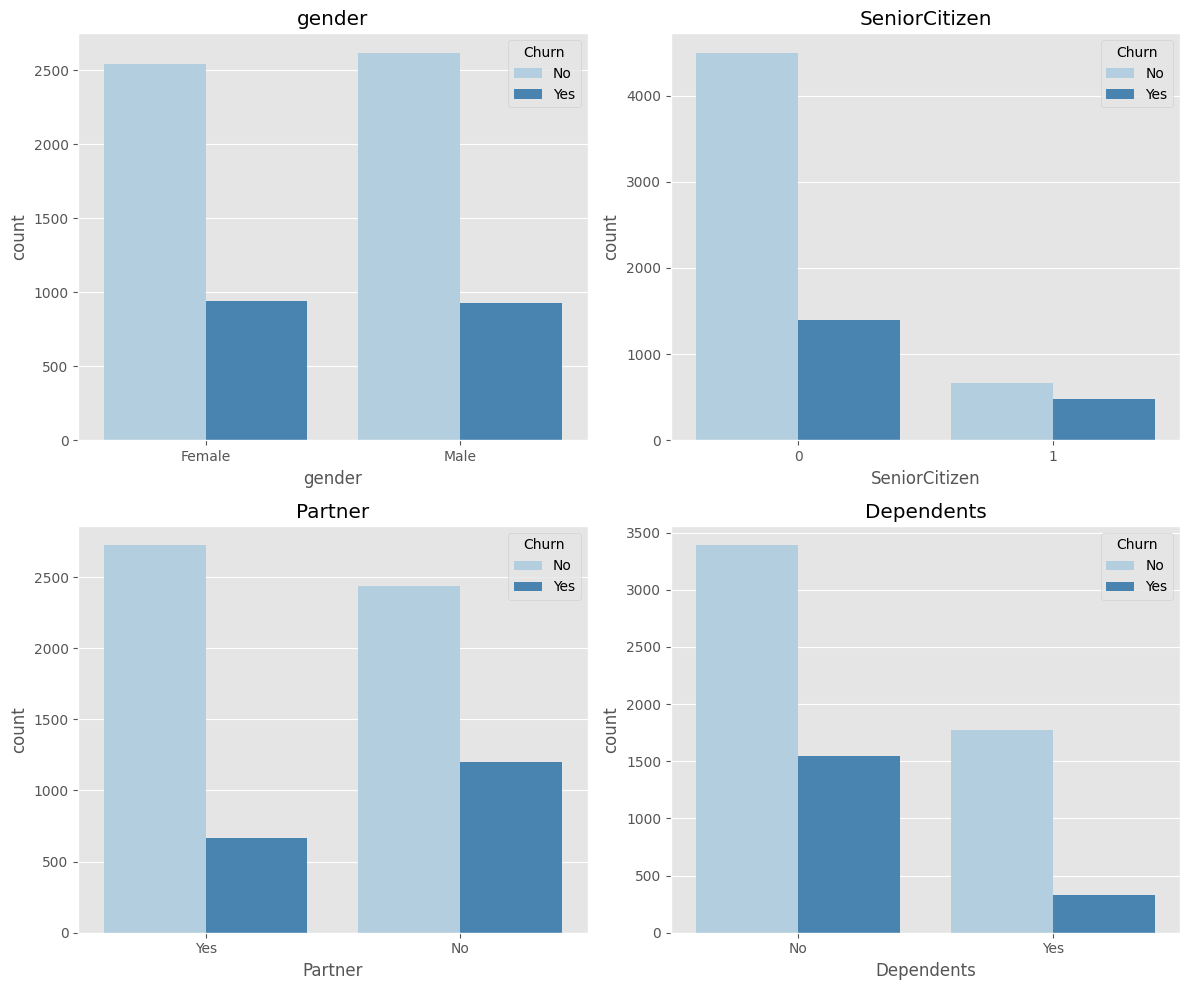

In [12]:
demographics = ["gender", "SeniorCitizen", "Partner", "Dependents"]
plot_categorical_to_target(df, demographics, "Churn")


- Il n'y a pas de différence notable de désabonnement selon le sexe.
- Les clients sans partenaire et sans personnes à charge se désabonnent plus fréquemment.
- Les personnes âgées (SeniorCitizen = 1) ont un taux de désabonnement proportionnellement plus élevé.


## Vérification des valeurs aberrantes (Outliers)


C:\Users\karlh\AppData\Local\Temp\ipykernel_25508\3858222253.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=column, data=df, palette="Blues", ax=ax)
C:\Users\karlh\AppData\Local\Temp\ipykernel_25508\3858222253.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=column, data=df, palette="Blues", ax=ax)
C:\Users\karlh\AppData\Local\Temp\ipykernel_25508\3858222253.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=column, data=df, palette="Blues", ax=ax)


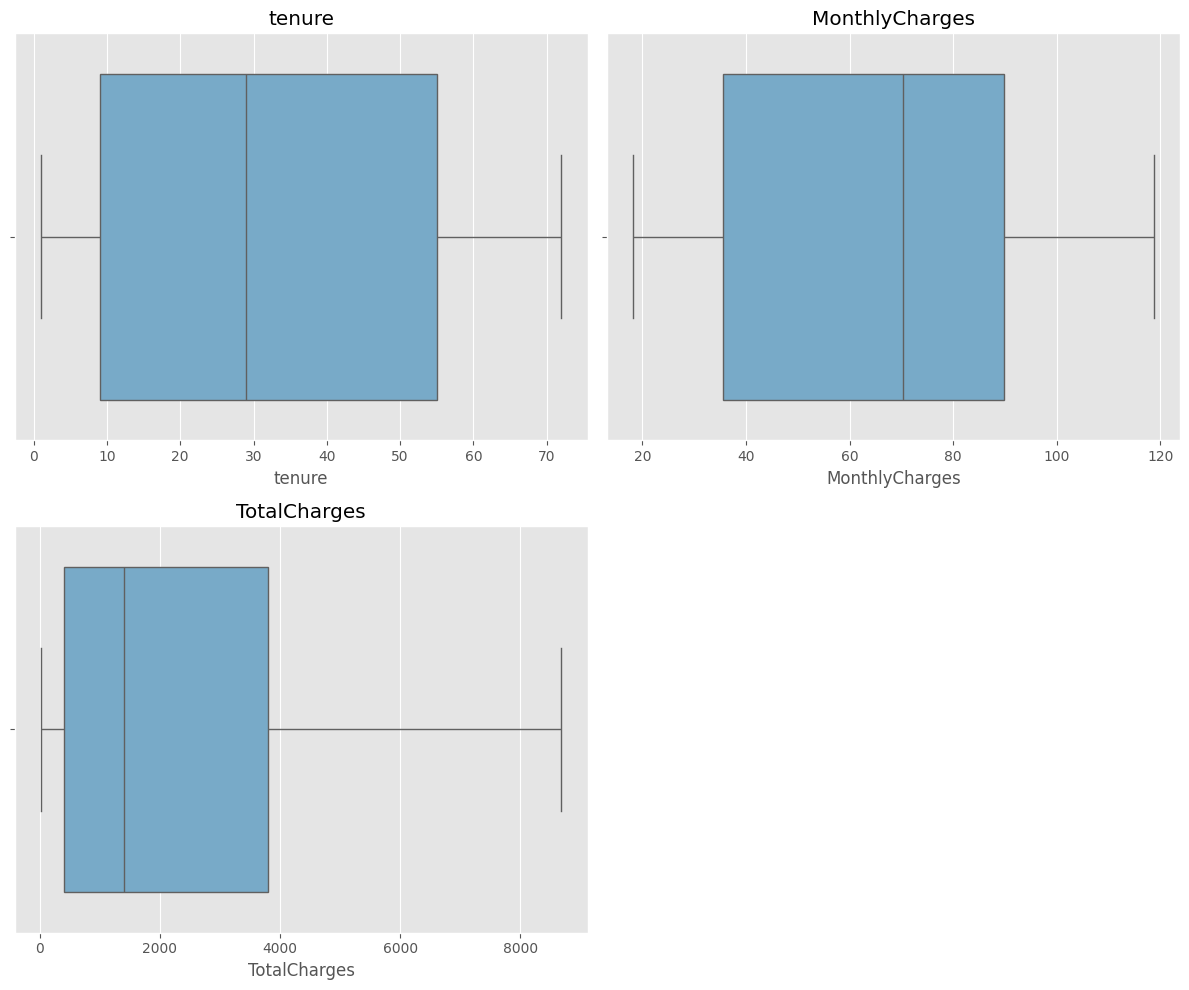

In [13]:
def outlier_check_boxplot(df, numerical_values):
    number_of_columns = 2
    number_of_rows = math.ceil(len(numerical_values) / number_of_columns)
    
    fig = plt.figure(figsize=(12, 5 * number_of_rows))
    for index, column in enumerate(numerical_values, 1):
        ax = fig.add_subplot(number_of_rows, number_of_columns, index)
        sns.boxplot(x=column, data=df, palette="Blues", ax=ax)
        ax.set_title(column)
    plt.tight_layout()
    plt.show()

outlier_check_boxplot(df, ["tenure", "MonthlyCharges", "TotalCharges"])


Les graphiques en boîte à moustaches montrent qu'il n'y a pas de valeurs aberrantes significatives dans nos colonnes numériques. Nous pouvons procéder à l'ingénierie des caractéristiques.


## Ingénierie des fonctionnalités (Feature Engineering)
### 1. Encodage des étiquettes (Label Encoding) pour les colonnes binaires


In [14]:
feature_le = ["Partner", "Dependents", "PhoneService", "Churn", "PaperlessBilling"]

def label_encoding(df, features):
    for i in features:
        df[i] = df[i].map({"Yes": 1, "No": 0})
    return df

df = label_encoding(df, feature_le)
df["gender"] = df["gender"].map({"Female": 1, "Male": 0})
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
5575-GNVDE,0,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
3668-QPYBK,0,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
7795-CFOCW,0,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer,42.30,1840.75,0
9237-HQITU,1,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


### 2. Encodage à chaud (One-Hot Encoding) pour les variables à multiples catégories


In [15]:
features_ohe = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", 
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", 
    "Contract", "PaymentMethod"
]
df_ohe = pd.get_dummies(df, columns=features_ohe, dtype=int)
print(f"Dimensions après One-Hot Encoding : {df_ohe.shape}")


Dimensions après One-Hot Encoding : (7032, 41)


### 3. Mise à l'échelle des variables numériques (MinMaxScaler)


In [16]:
features_mms = ["tenure", "MonthlyCharges", "TotalCharges"]
df_mms = pd.DataFrame(df_ohe, columns=features_mms)
df_remaining = df_ohe.drop(columns=features_mms)

mms = MinMaxScaler(feature_range=(0,1))
rescaled_feature = mms.fit_transform(df_mms)

rescaled_feature_df = pd.DataFrame(
    rescaled_feature, 
    columns=features_mms, 
    index=df_remaining.index
)

# Reconstruction du DataFrame avec les variables remises à l'échelle en premier
df_final = pd.concat([rescaled_feature_df, df_remaining], axis=1)
df_final.head()


,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0.000000,0.115423,0.001275,1,0,1,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
5575-GNVDE,0.464789,0.385075,0.215867,0,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,1
3668-QPYBK,0.014085,0.354229,0.010310,0,0,0,0,1,1,1,...,1,0,0,1,0,0,0,0,0,1
7795-CFOCW,0.619718,0.239303,0.210241,0,0,0,0,0,0,0,...,1,0,0,0,1,0,1,0,0,0
9237-HQITU,0.014085,0.521891,0.015330,1,0,0,0,1,1,1,...,1,0,0,1,0,0,0,0,1,0


### 4. Analyse de corrélation


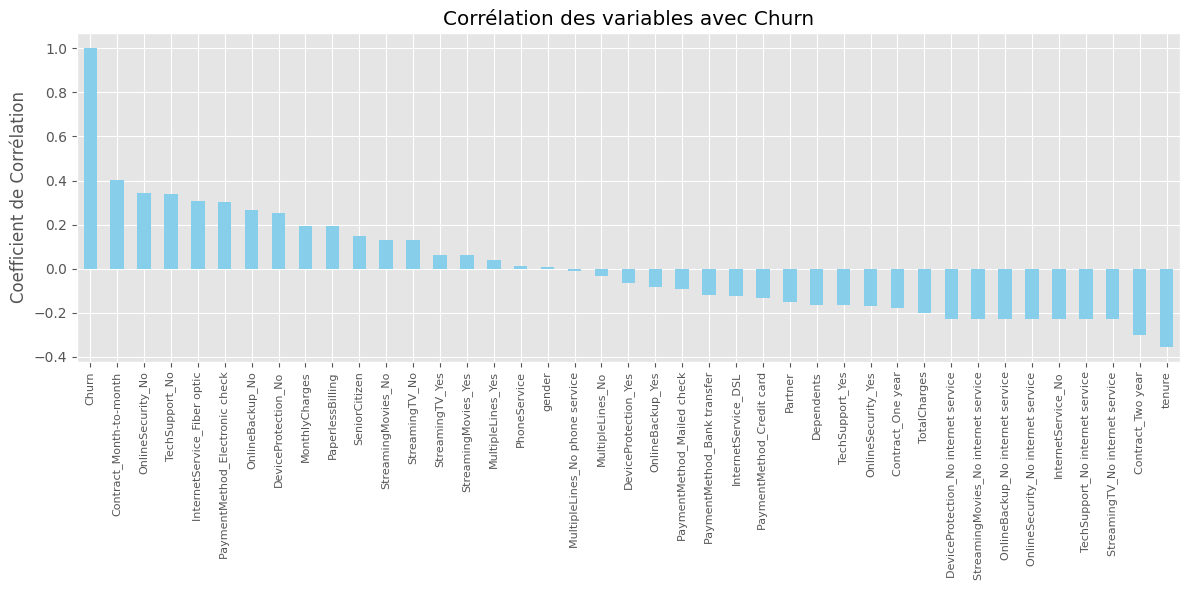

In [17]:
plt.figure(figsize=(12, 6))
df_final.corr()["Churn"].sort_values(ascending=False).plot(kind="bar", color="skyblue")
plt.title("Corrélation des variables avec Churn")
plt.ylabel("Coefficient de Corrélation")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()


## Division du jeu de données (Test / Train Split)


In [18]:
X = df_final.drop(columns="Churn")
y = df_final["Churn"]

# Répartition 80% train / 20% test, avec stratification de la variable cible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")


Train set: (5625, 40), Test set: (1407, 40)


## Création des fonctions d'affichage des mesures d'évaluation


In [19]:
# Poids des coefficients (pour la régression logistique)
def feature_weights(X_df, classifier, classifier_name):
    weights = pd.Series(classifier.coef_[0], index=X_df.columns.values).sort_values(ascending=False)
    
    top_10_weights = weights[:10]
    plt.figure(figsize=(7, 4))
    plt.title(f"{classifier_name} - Top 10 Features")
    top_10_weights.plot(kind="bar", color="coral")
    plt.show()
    
    bottom_10_weights = weights[-10:]
    plt.figure(figsize=(7, 4))
    plt.title(f"{classifier_name} - Bottom 10 Features")
    bottom_10_weights.plot(kind="bar", color="lightblue")
    plt.show()

# Affichage de la matrice de confusion
def confusion_matrix_plot(X_train, y_train, X_test, y_test, y_pred, classifier, classifier_name):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {classifier_name}")
    plt.grid(False)
    plt.show()
    
    print(f"Accuracy Score Test = {accuracy_score(y_test, y_pred):.4f}")
    print(f"Accuracy Score Train = {classifier.score(X_train, y_train):.4f}")
    print("\nClassification Report :\n", classification_report(y_test, y_pred))

# Courbe ROC et calcul de l'AUC
def roc_curve_auc_score(X_test, y_test, y_pred_probabilities, classifier_name):
    y_pred_prob = y_pred_probabilities[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    
    plt.figure(figsize=(6, 5))
    plt.plot([0,1], [0,1], "k--")
    plt.plot(fpr, tpr, label=f"{classifier_name} (AUC = {roc_auc_score(y_test, y_pred_prob):.4f})")
    plt.title(f"{classifier_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()
    print(f"AUC Score (ROC): {roc_auc_score(y_test, y_pred_prob):.4f}")

# Courbe Precision-Recall et F1 Score
def precision_recall_curve_and_scores(X_test, y_test, y_pred, y_pred_probabilities, classifier_name):
    y_pred_prob = y_pred_probabilities[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
    
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"{classifier_name} (PR AUC = {auc(recall, precision):.4f})")
    plt.title(f"{classifier_name} - Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="lower left")
    plt.show()
    
    f1 = f1_score(y_test, y_pred)
    pr_auc = auc(recall, precision)
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC Score (PR) : {pr_auc:.4f}")


## Modèle 1 : K-Nearest Neighbor (KNN)


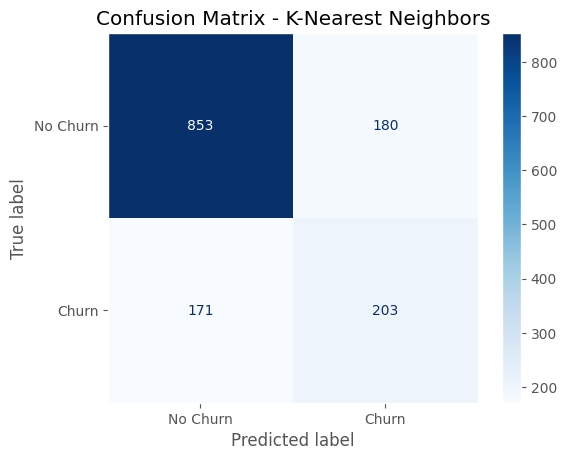

Accuracy Score Test = 0.7505
Accuracy Score Train = 0.8359

Classification Report :
               precision    recall  f1-score   support

           0       0.83      0.83      0.83      1033
           1       0.53      0.54      0.54       374

    accuracy                           0.75      1407
   macro avg       0.68      0.68      0.68      1407
weighted avg       0.75      0.75      0.75      1407



In [20]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_pred_knn_proba = knn.predict_proba(X_test)

# Matrice de confusion
confusion_matrix_plot(X_train, y_train, X_test, y_test, y_pred_knn, knn, "K-Nearest Neighbors")


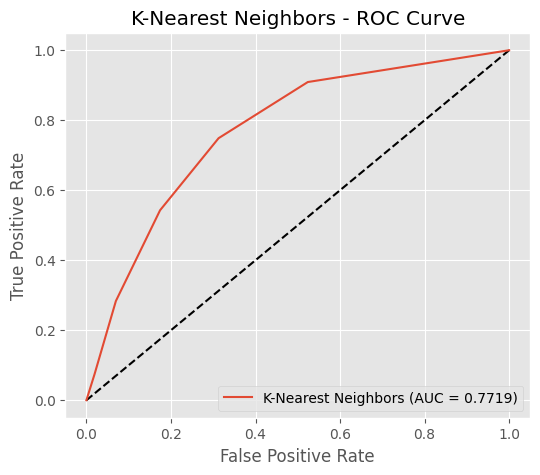

AUC Score (ROC): 0.7719


In [21]:
# Courbe ROC
roc_curve_auc_score(X_test, y_test, y_pred_knn_proba, "K-Nearest Neighbors")


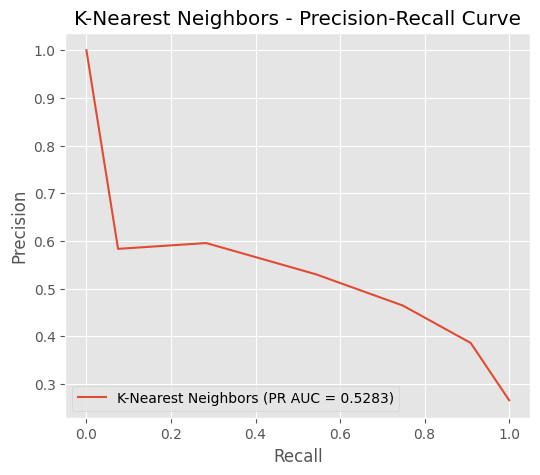

F1 Score : 0.5363
AUC Score (PR) : 0.5283


In [22]:
# Courbe Precision-Recall
precision_recall_curve_and_scores(X_test, y_test, y_pred_knn, y_pred_knn_proba, "K-Nearest Neighbors")


## Modèle 2 : Régression Logistique


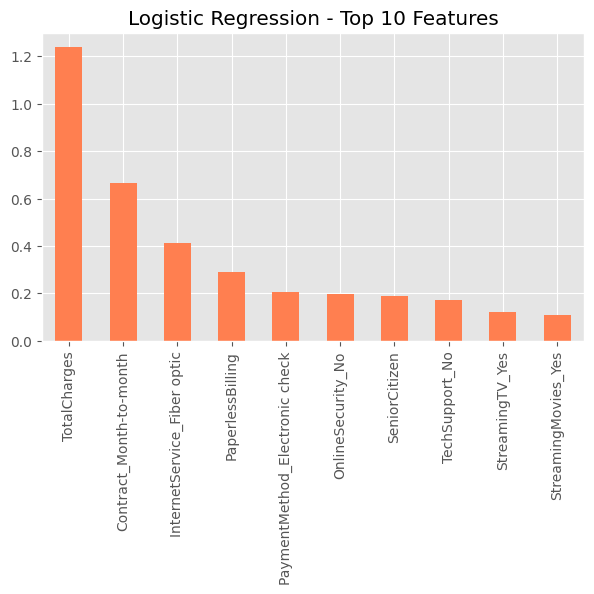

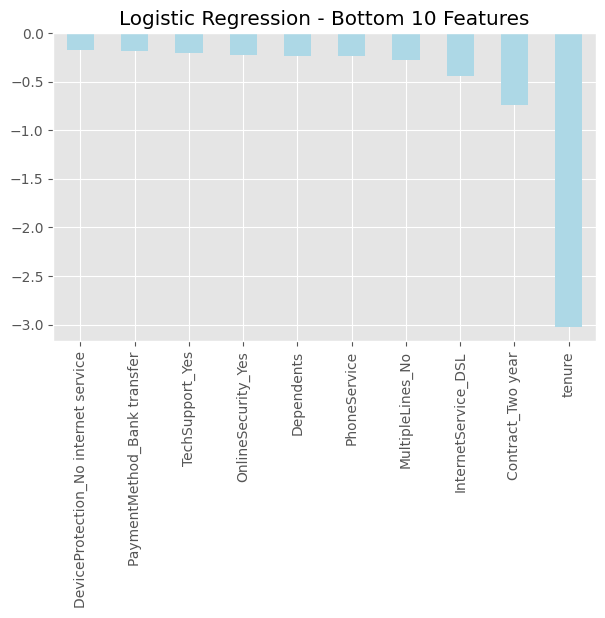

In [23]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)
y_pred_logreg_proba = logreg.predict_proba(X_test)

# Poids des coefficients
feature_weights(X_train, logreg, "Logistic Regression")


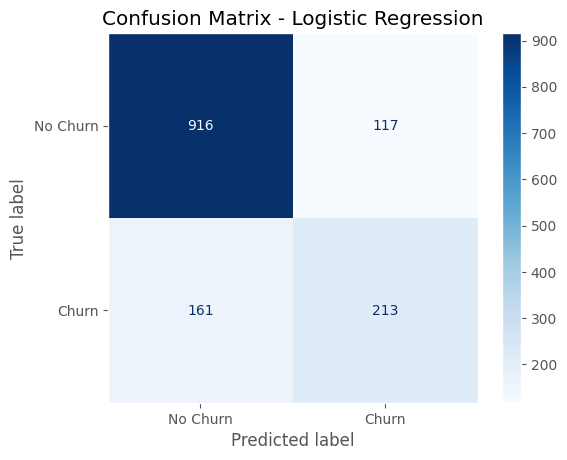

Accuracy Score Test = 0.8024
Accuracy Score Train = 0.8044

Classification Report :
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [24]:
# Matrice de confusion
confusion_matrix_plot(X_train, y_train, X_test, y_test, y_pred_logreg, logreg, "Logistic Regression")


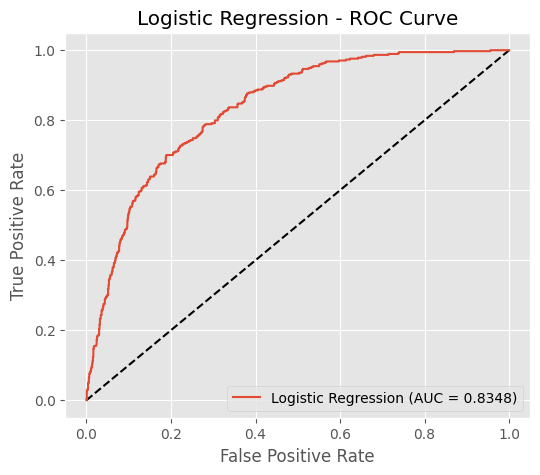

AUC Score (ROC): 0.8348


In [25]:
# Courbe ROC
roc_curve_auc_score(X_test, y_test, y_pred_logreg_proba, "Logistic Regression")


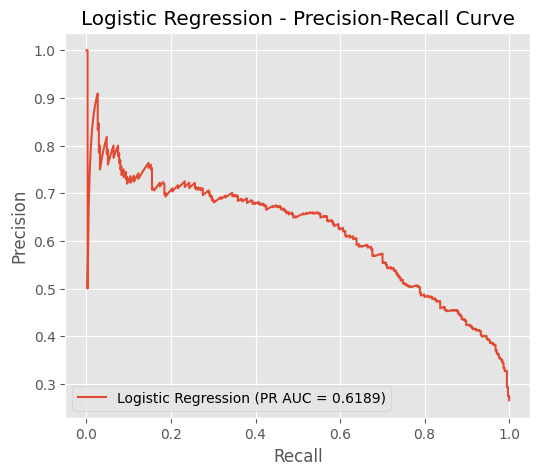

F1 Score : 0.6051
AUC Score (PR) : 0.6189


In [26]:
# Courbe Precision-Recall
precision_recall_curve_and_scores(X_test, y_test, y_pred_logreg, y_pred_logreg_proba, "Logistic Regression")


## Modèle 3 : Réseau de Neurones (MLPClassifier)
*(Cette section complète la fin du TP en implémentant un réseau de neurones artificiels multi-couches).*


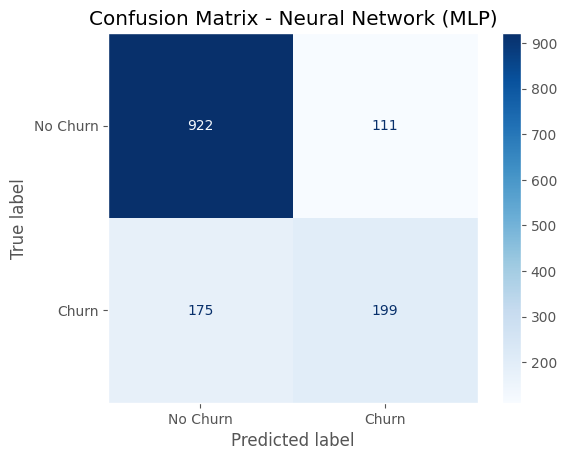

Accuracy Score Test = 0.7967
Accuracy Score Train = 0.8043

Classification Report :
               precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [27]:
# Définition et entraînement du Perceptron Multi-Couches (MLP)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32), 
    max_iter=1000, 
    activation='relu',
    solver='adam',
    early_stopping=True,
    random_state=42
)
mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)
y_pred_mlp_proba = mlp.predict_proba(X_test)

# Matrice de confusion
confusion_matrix_plot(X_train, y_train, X_test, y_test, y_pred_mlp, mlp, "Neural Network (MLP)")


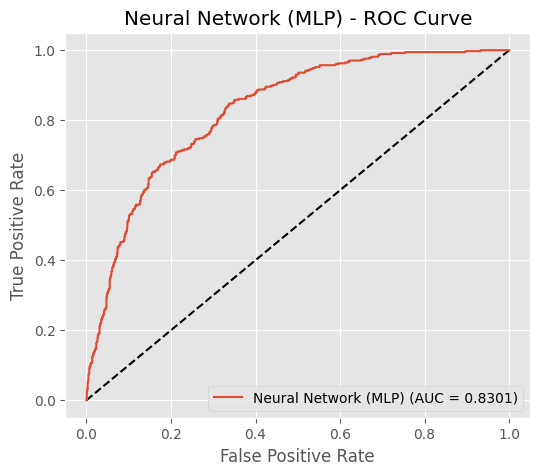

AUC Score (ROC): 0.8301


In [28]:
# Courbe ROC
roc_curve_auc_score(X_test, y_test, y_pred_mlp_proba, "Neural Network (MLP)")


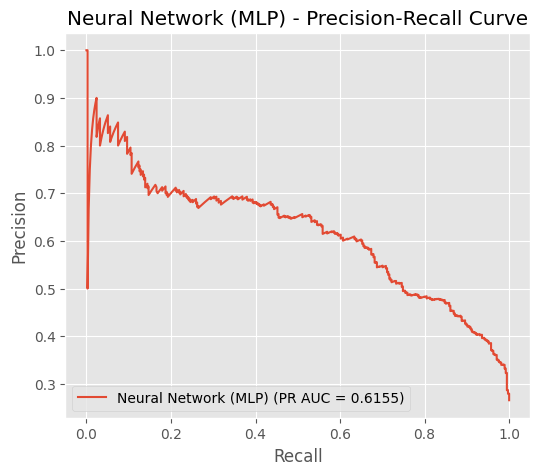

F1 Score : 0.5819
AUC Score (PR) : 0.6155


In [29]:
# Courbe Precision-Recall
precision_recall_curve_and_scores(X_test, y_test, y_pred_mlp, y_pred_mlp_proba, "Neural Network (MLP)")


## Synthèse comparative
Affichons les métriques clés de nos trois modèles pour conclure sur le plus performant.


In [30]:
models_summary = pd.DataFrame({
    "Modèle": ["K-Nearest Neighbors", "Régression Logistique", "Réseau de Neurones (MLP)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_mlp)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_mlp)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_pred_knn_proba[:, 1]),
        roc_auc_score(y_test, y_pred_logreg_proba[:, 1]),
        roc_auc_score(y_test, y_pred_mlp_proba[:, 1])
    ]
})

models_summary.set_index("Modèle")


,Accuracy,F1-Score,ROC AUC
Modèle,,,
K-Nearest Neighbors,0.750533,0.536328,0.771877
Régression Logistique,0.802416,0.605114,0.834832
Réseau de Neurones (MLP),0.796731,0.581871,0.830118


### Conclusion finale :
- La **Régression Logistique** et le **Réseau de Neurones (MLP)** surperforment nettement le modèle KNN.
- La Régression Logistique offre une excellente interprétabilité grâce à ses coefficients directeurs, tandis que le Réseau de Neurones peut capturer des relations non-linéaires subtiles.
- Les performances (ROC AUC ~0.835) sont très satisfaisantes et prêtes à être intégrées dans un outil d'aide à la décision.
